In [2]:
import os
from dotenv import load_dotenv, find_dotenv

_ = load_dotenv(find_dotenv())

In [3]:
#import all the necessary langchain packages
from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory

## ConversationChain

`ConversationChain` is a chain that wraps an LLM and automatically manages the flow of a conversation - it builds the prompt (adding the conversation history + your new input) and calls the LLM for you, so you don't have to manually track past messages yourself.

## ConversationBufferMemory

`ConversationBufferMemory` is used to create a conversation memory to hold up the conversation. It stores every message (Human + AI) exchanged so far as plain text, so that on the next turn the Chain can include that full history in the prompt - this is what gives the illusion that the model "remembers" earlier messages, when really the whole transcript is just being re-sent every time.


In [4]:
llm = ChatOpenAI(temperature = 0.0, model = "gpt-3.5-turbo") #initialize the model
memory = ConversationBufferMemory() 
conversation = ConversationChain(
    llm = llm,
    memory = memory,
    verbose = True    # prints the full prompt sent to the LLM for each call (instructions + history + new input), useful for seeing what's actually happening behind the scenes
)

In [6]:
conversation.predict(input = "Hey, I am Akhilesh, how are you?")



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:

Human: Hey, I am Akhilesh, how are you?
AI:

> Finished chain.


"Hello Akhilesh! I'm doing well, thank you for asking. How can I assist you today?"

In [7]:
conversation.predict(input = "can you introduce yourself?")



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
Human: Hey, I am Akhilesh, how are you?
AI: Hello Akhilesh! I'm doing well, thank you for asking. How can I assist you today?
Human: can you introduce yourself?
AI:

> Finished chain.


"Of course! I am an artificial intelligence designed to provide information and assistance to users like you. My programming allows me to analyze data, answer questions, and engage in conversations on a wide range of topics. I'm here to help with anything you need."

In [8]:
conversation.predict(input = "do you remember my name?")



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
Human: Hey, I am Akhilesh, how are you?
AI: Hello Akhilesh! I'm doing well, thank you for asking. How can I assist you today?
Human: can you introduce yourself?
AI: Of course! I am an artificial intelligence designed to provide information and assistance to users like you. My programming allows me to analyze data, answer questions, and engage in conversations on a wide range of topics. I'm here to help with anything you need.
Human: do you remember my name?
AI:

> Finished chain.


"Yes, your name is Akhilesh. It's nice to chat with you again!"

In [9]:
print(memory)

chat_memory=ChatMessageHistory(messages=[HumanMessage(content='Hey, I am Akhilesh, how are you?', additional_kwargs={}, example=False), AIMessage(content="Hello Akhilesh! I'm doing well, thank you for asking. How can I assist you today?", additional_kwargs={}, example=False), HumanMessage(content='can you introduce yourself?', additional_kwargs={}, example=False), AIMessage(content="Of course! I am an artificial intelligence designed to provide information and assistance to users like you. My programming allows me to analyze data, answer questions, and engage in conversations on a wide range of topics. I'm here to help with anything you need.", additional_kwargs={}, example=False), HumanMessage(content='do you remember my name?', additional_kwargs={}, example=False), AIMessage(content="Yes, your name is Akhilesh. It's nice to chat with you again!", additional_kwargs={}, example=False)]) output_key=None input_key=None return_messages=False human_prefix='Human' ai_prefix='AI' memory_key=

In [10]:
print(memory.buffer) #prints in a readable manner

Human: Hey, I am Akhilesh, how are you?
AI: Hello Akhilesh! I'm doing well, thank you for asking. How can I assist you today?
Human: can you introduce yourself?
AI: Of course! I am an artificial intelligence designed to provide information and assistance to users like you. My programming allows me to analyze data, answer questions, and engage in conversations on a wide range of topics. I'm here to help with anything you need.
Human: do you remember my name?
AI: Yes, your name is Akhilesh. It's nice to chat with you again!


In [11]:
memory.load_memory_variables({}) #empty dict here because ConversationBufferMemory doesn't need any extra input to decide what to return - it just returns everything it has. Some other memory types (e.g. vector-store backed memory) need you to pass something like {"input": "..."} so they know what to search for


{'history': "Human: Hey, I am Akhilesh, how are you?\nAI: Hello Akhilesh! I'm doing well, thank you for asking. How can I assist you today?\nHuman: can you introduce yourself?\nAI: Of course! I am an artificial intelligence designed to provide information and assistance to users like you. My programming allows me to analyze data, answer questions, and engage in conversations on a wide range of topics. I'm here to help with anything you need.\nHuman: do you remember my name?\nAI: Yes, your name is Akhilesh. It's nice to chat with you again!"}

### How the Chain and the Memory communicate behind the scenes

**1. What `.load_memory_variables()` does**

This method is the "fetch" command. When you run `conversation.predict()`, the Chain doesn't just magically know the past conversation - it explicitly calls `.load_memory_variables()` on the Memory object.

This method's job is to retrieve the stored chat transcript and format it so the Chain can plug it directly into the prompt template we saw earlier.

**2. Why it outputs a dictionary with the key `"history"`**

LangChain relies heavily on string formatting. The default prompt template for a `ConversationChain` looks something like this under the hood:

```
The following is a friendly conversation...
Current conversation:
{history}
Human: {input}
AI:
```

The Chain needs to fill in those `{history}` and `{input}` placeholders. So `.load_memory_variables()` returns a dictionary where the key (`"history"`) matches the exact variable name expected by the prompt template, and the value is the giant string of previous messages.


## Manually saving context

You can also append the conversation history directly by yourself, using `.save_context({input}, {output})`.


In [12]:
memory = ConversationBufferMemory() #new memory initialized

In [15]:
memory.save_context({"input": "Hey"}, {"output": "Hey there, what's up with you"}) #save_context takes two dicts - {"input": ...} for the human side and {"output": ...} for the AI side. Internally these get formatted as "Human: ..." / "AI: ..." in the buffer


In [16]:
print(memory.buffer)

Human: Hey
AI: Hey, there what's up with you


In [17]:
memory.load_memory_variables({})

{'history': "Human: Hey\nAI: Hey, there what's up with you"}

## ConversationBufferWindowMemory

In [18]:
from langchain.memory import ConversationBufferWindowMemory

In [ ]:
memory = ConversationBufferWindowMemory(k=1) # k=1 means only the most recent conversation is kept in memory


In [22]:
memory.save_context({"input": "Hey"}, {"output": "Hello"})
memory.save_context({"input": "can you introduce yourself?"}, {"output": "Of course! I am an artificial intelligence designed to provide information and assistance to users like you. My programming allows me to analyze data, answer questions, and engage in conversations on a wide range of topics. I'm here to help with anything you need."})
print(memory.load_memory_variables({}))

{'history': "Human: can you introduce yourself?\nAI: Of course! I am an artificial intelligence designed to provide information and assistance to users like you. My programming allows me to analyze data, answer questions, and engage in conversations on a wide range of topics. I'm here to help with anything you need."}


See? It doesn't remember the second-to-last exchange.

Having a long conversation history may waste tokens, so it's best to either limit the context window or summarize the conversation.

Another way to limit the token usage is to use ConversationTokenBufferMemory

In [23]:
from langchain.memory import ConversationTokenBufferMemory

In [24]:
chat = ChatOpenAI(model = "gpt-3.5-turbo", temperature = 0)

memory = ConversationTokenBufferMemory(llm=chat, max_token_limit=50)

memory.save_context({"input": "AI is what?!"},
                    {"output": "Amazing!"})
memory.save_context({"input": "Backpropagation is what?"},
                    {"output": "Beautiful!"})
memory.save_context({"input": "Chatbots are what?"}, 
                    {"output": "Charming!"})

In [25]:
memory.load_memory_variables({})

{'history': 'AI: Amazing!\nHuman: Backpropagation is what?\nAI: Beautiful!\nHuman: Chatbots are what?\nAI: Charming!'}

## ConversationSummaryBufferMemory

In [26]:
from langchain.memory import ConversationSummaryBufferMemory

In [27]:
# create a long string
schedule = "There is a meeting at 8am with your product team. \
You will need your powerpoint presentation prepared. \
9am-12pm have time to work on your LangChain \
project which will go quickly because Langchain is such a powerful tool. \
At Noon, lunch at the italian restaurant with a customer who is driving \
from over an hour away to meet you to understand the latest in AI. \
Be sure to bring your laptop to show the latest LLM demo."


In [28]:
memory = ConversationSummaryBufferMemory(llm = chat, max_token_limit = 100)

memory.save_context({"input": "Hello"}, {"output": "What's up"})
memory.save_context({"input": "Not much, just hanging"},
                    {"output": "Cool"})
memory.save_context({"input": "What is on the schedule today?"}, 
                    {"output": f"{schedule}"})

In [30]:
memory.load_memory_variables({})

{'history': 'System: The human and AI exchange greetings and discuss the schedule for the day, including a meeting with the product team, work on the LangChain project, and a lunch meeting with a customer interested in AI. The AI provides details on each event and emphasizes the power of LangChain as a tool.'}

The LLM does the actual summarizing, but LangChain is the manager that tells it to do so.

**1. LangChain's role: the manager**

LangChain acts as the trigger and the orchestrator. Because you set `max_token_limit = 100`, LangChain is constantly doing math in the background, counting the length of your conversation.

Once your messages exceed that 100-token limit, LangChain steps in. It takes the oldest messages in the buffer, wraps them in a hidden "summarization prompt" (something like: "Progressively summarize the lines of conversation provided..."), and routes that prompt to the LLM.

**2. The LLM's role: the summarizer**

LangChain itself does not have a brain, so it cannot write a summary. That's why you had to pass `llm = chat` into the memory configuration.

When LangChain realizes the buffer is too full, it sends the hidden summarization prompt to the LLM. The LLM reads the old messages, generates the exact summary text you see in the output ("The human and AI exchange greetings..."), and hands that text back to LangChain.


In [32]:
conversation = ConversationChain(
    llm = chat,
    memory = memory,
    verbose = True
)

conversation.predict(input = "What would be a good demo to show?")



> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:
System: The human and AI exchange greetings and discuss the schedule for the day, including a meeting with the product team, work on the LangChain project, and a lunch meeting with a customer interested in AI. The AI provides details on each event and emphasizes the power of LangChain as a tool.
Human: What would be a good demo to show?
AI:

> Finished chain.


'For the meeting with the product team, a demo showcasing the latest features and updates on the LangChain project would be ideal. This could include a live demonstration of how LangChain streamlines language translation processes, improves accuracy, and increases efficiency. Additionally, highlighting any recent success stories or case studies would be beneficial to showcase the real-world impact of LangChain.'

The summarized part of the conversation is stored under the label `System:` (confirmed) - so the buffer ends up looking something like: `System: <summary of older messages>\nHuman: <latest input>\nAI: <latest output>`. That makes sense, since the summary isn't literally something either the Human or the AI said - it's metadata the system generated to compress older history.


In [33]:
memory.load_memory_variables({})

{'history': 'System: The human and AI exchange greetings and discuss the schedule for the day, including a meeting with the product team, work on the LangChain project, and a lunch meeting with a customer interested in AI. The AI provides details on each event and emphasizes the power of LangChain as a tool.\nHuman: What would be a good demo to show?\nAI: For the meeting with the product team, a demo showcasing the latest features and updates on the LangChain project would be ideal. This could include a live demonstration of how LangChain streamlines language translation processes, improves accuracy, and increases efficiency. Additionally, highlighting any recent success stories or case studies would be beneficial to showcase the real-world impact of LangChain.'}

So the summary and the last exchange are stored without any issues, since together they don't exceed the token limit.

![Screenshot 2026-08-04 220917](<attachment:Screenshot 2026-08-04 220917.png>)
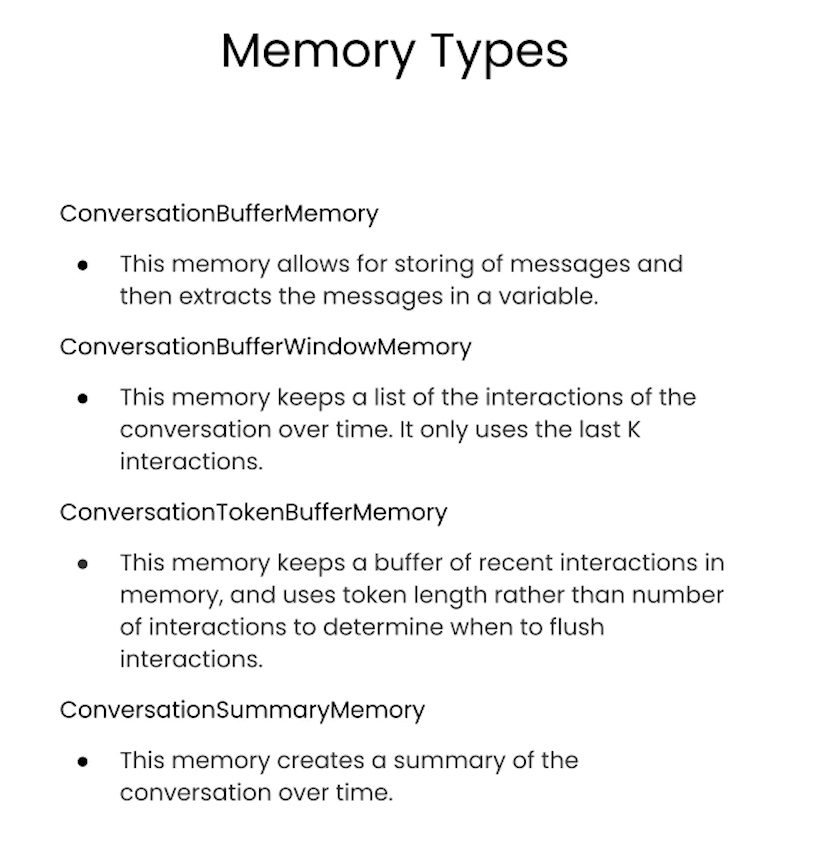

![Screenshot 2026-08-04 221004.png](<attachment:Screenshot 2026-08-04 221004.png>)
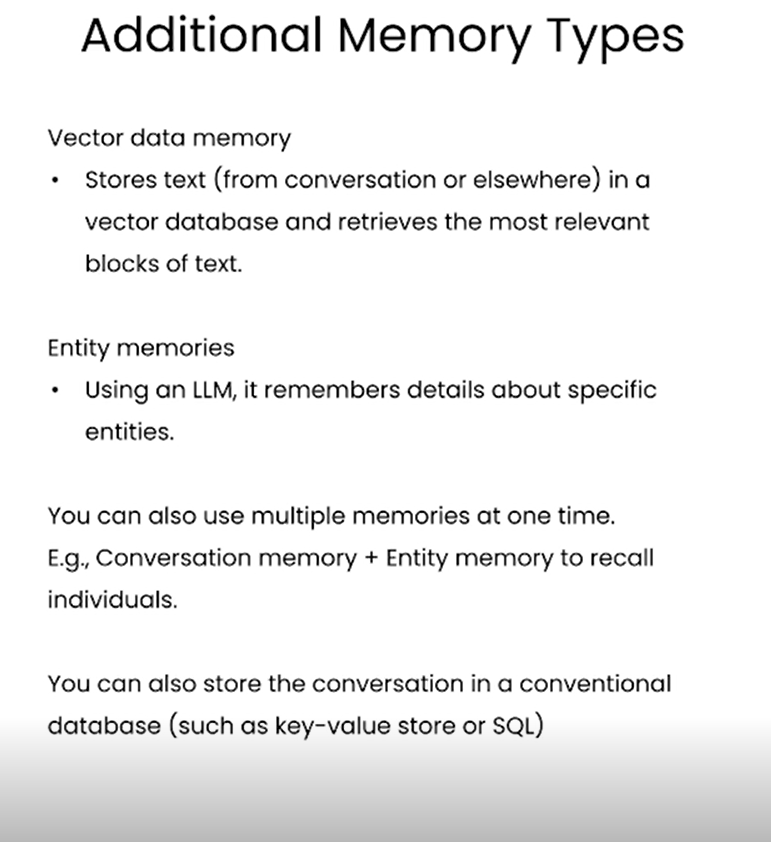
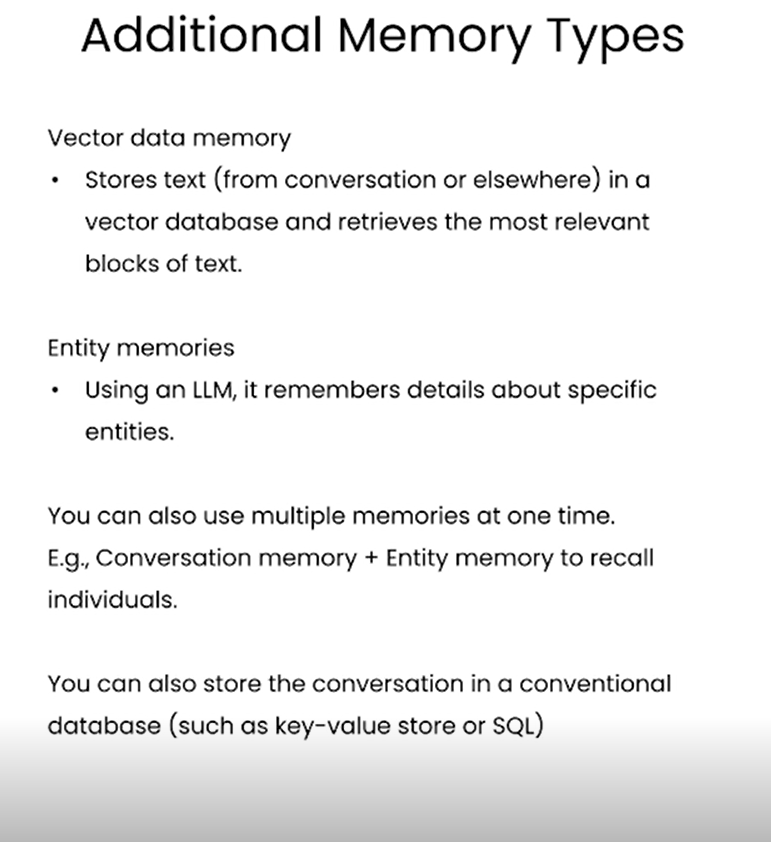